# Getting started

## Overview

This Jupyter notebook allows the specification of the run mode and various analysis parameters. 

## Run modes

The notebook can be run in two modes: 
1. **Single file processing**
   - The notebook will only process one specified file and will load the original and the calculated pixel variance stacks in the Napari viewer for visual inspection. Results will be saved automatically in an "analysis" folder which will be created in the indicated directory. 
2. **Batch processing**
   - The notebook will process all tiff or ome.tiff files located in the indicated input folder. The Napari viewer will not be used to free up memory after every processed file. Results will be saved automatically in an "analysis" folder which will be created in the indicated directory.
  
## Input parameters and options

1. Directory
   - The directory in which the file(s) to be processed is/are located. 
2. Checkbox option for batch processing
   - Tick the box to process all ome.tiff/tiff files located within the indicated directory. Batch mode is the defaultrun mode.
   - If the box is not ticked, a file located within the directory folder needs to be specified. Copy and past the file name including the file extension.
3. File name
   - Only required when not batch processing
4. Video rate (fps)
   - In batch mode, all files will be processed using this video rate. Ensure that the directory only contains files recorded with the same frame rate.
5. Beat Rate (Hz)
   - In batch mode, all files will be processed using this beat rate. Ensure that the directory only contains images where the sample exhibits the same beat rate.
6. Offset (frames)
   - Add an integer value to manually specify the offset number of frames. Be sure to untick the Checkbox "Calculate offset from video rate & beat rate" otherwise this number will be overwritten.
7. Checkbox option for calculating the offset from video rate & beat rate
   - The calculation follows the formula: $$ offset = fractional offset * (video rate (fps) / beat rate (Hz)) $$
   - Fractional offset: set a fraction between 0 and 1.
8. Checkbox option to calibrate the calculated speed/contraction values with a pixel calibration.
   - If the pixel calibration, e.g. 1.38 micron/pixel, is known, enter that value in the box below.
   - The calculated speed and contraction values will then be scaled accordingly. 
   - If the pixel calibration is not known, untick the box and the generated results will be in px/s and px for speed and contraction respectively.
9. Pixel calibration.
   - The expected unit is micron.
  
Once all parameters are set, click on the "Submit Parameters" button and move on to the next code cell. 

In [1]:
# ---- Import utility functions ----
import napari
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft
from scipy.signal import windows, savgol_filter, find_peaks, detrend
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- User input dialog ---- 
# Input widgets
input_directory_input = widgets.Text(
    #value=r'C:\Users\mheldb\Documents\Image_analysis\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\input-data\full_experiments\Exp11',
    value=r'C:\Users\mheldb\Documents\Image_analysis\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\paper-data',
    #value=r'C:\Users\directory',
    #value='C:/Users/directory',
    description='Directory:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='600px')
)

checkbox_batch_processing = widgets.Checkbox(
    value=False,
    description='Process all ome.tiff, tiff files in directory above.',
    indent=False,
    style={'description_width': 'auto'}
)

file_name_info_message = widgets.HTML(
    value='<i>A filename is only required when the batch option is not ticked.</i>',
)

input_file_input = widgets.Text(
    value='ContractionWave_hIPSC-CM_CTR_stills.tif',
    #value='time-lapse-file.ome.tif',
    description='File name:',
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='400px')
)

video_rate_input = widgets.IntText(
    value=100,
    description='Video rate (fps):',
    style={'description_width': 'auto'}
)

beat_rate_calculation_info_message = widgets.HTML(
    value='<i>The beat rate value will be overwritted if "Calculate beat rate" box is ticked.</i>',
)

checkbox_beat_rate_calculation = widgets.Checkbox(
    value=True,
    description='Calculate beat rate from input data.',
    indent=False,
    style={'description_width': 'auto'}
)

exp_beat_rate_input = widgets.FloatText(
    value=1,
    description='Manual beat rate (Hz):',
    style={'description_width': 'auto'}
)

offset_input = widgets.FloatText(
    value=15,
    description='Offset (frames):',
    style={'description_width': 'auto'}
)

offset_calculation_info_message = widgets.HTML(
    value='<i>The Offset value will be overwritted if "Calculate offset" box is ticked.</i>',
)

checkbox_offset_calculation_input = widgets.Checkbox(
    value=True,
    description='Calculate offset from video rate & beat rate.',
    indent=False,
    style={'description_width': 'auto'}
)

offset_fraction_input = widgets.FloatText(
    value = 0.2, 
    description='Fractional offset for automated calculation. ',
    indent = False, 
    style={'description_width': 'auto'}
)

checkbox_calibration_w_pixel_size = widgets.Checkbox(
    value=False,
    description='Calibrate speed/contraction with pixel calibration below.' ,
    indent=False,
    style={'description_width': 'auto'},
    layout=widgets.Layout(width='600px')
)

pixel_calibration_input = widgets.FloatText(
    value=1,
    description='Pixel Calibration (µm/px):',
    style={'description_width': 'auto'}
)

# Run button
run_button = widgets.Button(
    description='Submit parameters',
    button_style='success',
    icon='check'
)

# Output area
output = widgets.Output()

# Define action on button click
def on_run_button_clicked(b):
    with output:
        clear_output()
        directory = input_directory_input.value
        auto_batch = checkbox_batch_processing.value
        file_name_info = file_name_info_message.value
        filename = input_file_input.value
        video_rate = video_rate_input.value
        beat_rate_info = beat_rate_calculation_info_message.value
        auto_beat_rate = checkbox_beat_rate_calculation.value
        beat_rate = exp_beat_rate_input.value
        offset = offset_input.value
        offset_calculation_info = offset_calculation_info_message.value
        auto_offset = checkbox_offset_calculation_input.value
        offset_fraction = offset_fraction_input.value
        auto_calibration = checkbox_calibration_w_pixel_size.value
        pixel_calibration = pixel_calibration_input.value
        
        offset = None
        if auto_offset:
            offset = int(offset_fraction_input.value * video_rate / beat_rate)
        else: 
            offset = int(offset_input.value)
        
        print(f"Thanks for initiating the analysis. Run the next cell to analyse the specified dataset.")
run_button.on_click(on_run_button_clicked)

# Display form
form = widgets.VBox([
    input_directory_input,
    checkbox_batch_processing, 
    file_name_info_message, 
    input_file_input,
    video_rate_input,
    beat_rate_calculation_info_message,
    checkbox_beat_rate_calculation,
    exp_beat_rate_input,
    offset_input,
    offset_calculation_info_message, 
    checkbox_offset_calculation_input,
    offset_fraction_input, 
    checkbox_calibration_w_pixel_size, 
    pixel_calibration_input,
    run_button,
    output
])

display(form)

# Analysis and automated result saving

The following steps are performed autonomously when running the cell below

1. **Save analysis parameters**

    - The parameters specified above will be saved automatically in a file called [OriginalFileName_processing_params.txt] in a folder called [analysis] that will automatically be created in the same directory as the file(s) to be processed. This is for documentation, accountability and reproducibility purposes. 

2. **Import transmitted light time series image data**

    - In single file analysis mode, once the input data has been imported, the image data will then be displayed in the napari viewer which will open automatically.
    - In batch mode napari will not be initiated and no images will be displayed. 

3. **Optional automated beat rate detection**

    - The beat rate of the imaged object will be calculated from the regular change of intensities in the input image. 

4. **Analysis**

    - Depending on the number of files to be processed and the size of the input file (number ofpixels per frame and time points) the analysis might take some time to run. First, the pixel variance is calculated and from that the speed and contraction data. Please be patient as the processing depends on the size of the input data and the hardware the notebook is run on. The console prints update statements for each major analysis step and file to indicate that the analysis is progressing.   

4. **Generating speed and contraction plots**

    - The underlying tables and plots for the calibrated and normalised speed and contraction are generated and automatically saved in the analysis directory carrying the input file name with appropriate suffixes. If the calibration check box is unticked, the "calibrated" numverical values/plots will be in pixels as unit.

5. **Plot pixel variance with raw input data**

    - The start of the pixel variance stack is padded with black frames according to the set offset parameter. This is to align the raw and pixel variance data for display and overlay purposes. The padded pixel variance stack is then saved as an ome.tiff file.
    - In single file mode, the padded pixel variance stack will be displayed in the napari viewer.  


Output will be written to: C:\Users\mheldb\Documents\Image_analysis\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\paper-data\analysis

Processing file 1/1.

--- Processing S-EPMC7810870_41598_2020_80848_MOESM4_ESM.tif ---

Importing image data. ...
Calculating beat rate from input time series.
Calculated beat rate: 0.46 Hz,  27.6 BPM


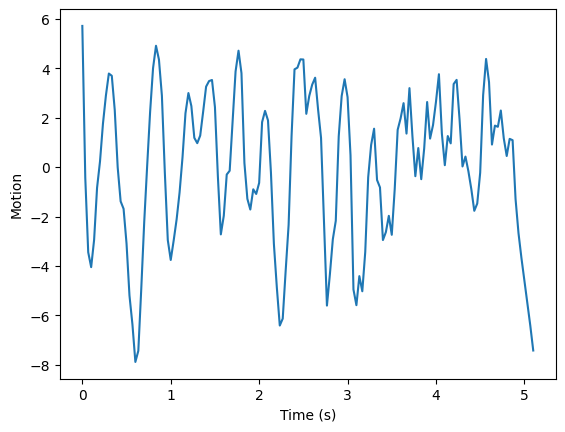

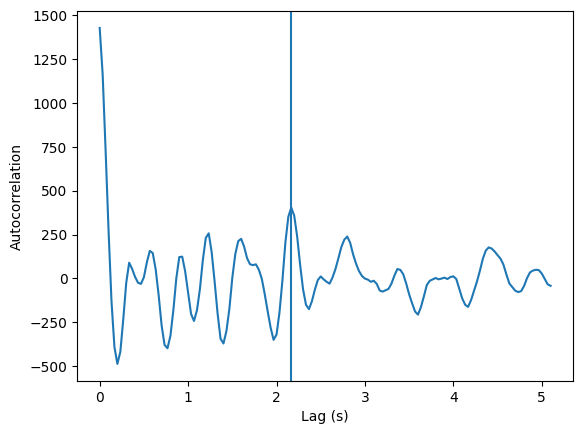

Calculating beat rate from input time series using FFT, detrending and adaptive determination.
Detected beat rate: 0.72 Hz or 83.08 BPM


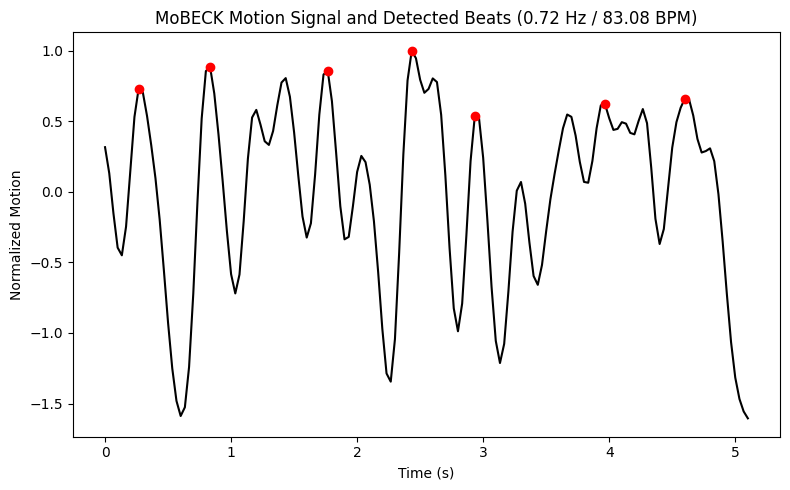


*** Full analysis pipeline is finshed. Thank you for your patience. :) ***


In [2]:
from pathlib import Path

# ----------------------------
# Helpers: input & file listing
# ----------------------------

def is_ome_tiff(p: Path):
    return p.suffix.lower() in {".tif", ".tiff"} or any(
        str(p).lower().endswith(ext) for ext in [".ome.tif", ".ome.tiff"]
    )


def collect_input_files():
    input_directory = Path(input_directory_input.value).expanduser().resolve()

    if not input_directory.is_dir():
        raise ValueError(f"Not a directory: {input_directory}")

    auto_batch = checkbox_batch_processing.value

    if auto_batch:
        files = sorted(
            [p for p in input_directory.iterdir() if p.is_file() and is_ome_tiff(p)]
        )
        print("List of files in the directory that will be processed: ")
        for p in files:
            print(p.name)

        if not files:
            raise RuntimeError("No .tif/.tiff/.ome.tiff files found in the folder.")
    else:
        files = [input_directory / input_file_input.value]

    return input_directory, files, auto_batch


def create_output_directory(input_directory: Path):
    output_directory = input_directory / "analysis"
    output_directory.mkdir(exist_ok=True)
    print(f"\nOutput will be written to: {output_directory}\n")
    return output_directory


# ----------------------------
# Helpers: parameters & naming
# ----------------------------

def collect_processing_parameters():
    video_rate = video_rate_input.value
    auto_beat_rate = checkbox_beat_rate_calculation.value
    exp_beat_rate = exp_beat_rate_input.value
    offset = int(offset_input.value)

    auto_offset = checkbox_offset_calculation_input.value
    if auto_offset:
        offset = int(offset_fraction_input.value * video_rate / exp_beat_rate)

    auto_calibration = checkbox_calibration_w_pixel_size.value
    pixel_calibration = pixel_calibration_input.value

    return {
        "video_rate": video_rate,
        "auto_beat_rate": auto_beat_rate, 
        "exp_beat_rate": exp_beat_rate,
        "offset": offset,
        "auto_offset": auto_offset,
        "auto_calibration": auto_calibration,
        "pixel_calibration": pixel_calibration,
    }


def get_filename_without_extension(input_file: Path):
    suffixes = input_file.suffixes
    if suffixes == [".ome", ".tiff"]:
        return input_file.stem.replace(".ome", "")
    return input_file.stem


def write_processing_parameters(
    output_directory, filename, input_file, params
):    
    with open(output_directory / f"{filename}_processing_params.txt", "w") as f:
        f.write(f"Output directory: {output_directory}\n")
        f.write(f"File: {input_file}\n")
        f.write(f"Video rate: {params['video_rate']} fps\n")        
        f.write(f"Auto beat rate calculation: {params['auto_beat_rate']} \n")
        if not params['auto_beat_rate']: 
            f.write(f"Beat rate: {params['exp_beat_rate']} Hz\n")
        f.write(f"Offset: {params['offset']}\n")
        f.write(f"Auto offset calc: {params['auto_offset']}\n")
        f.write(f"Calculated offset: {params['offset']}\n")
        f.write(f"Offset fraction: {offset_fraction_input.value}\n")
        f.write(f"Pixel calibration application: {params['auto_calibration']}\n")
        f.write(f"Pixel calibration: {params['pixel_calibration']}\n")


# ----------------------------
# Helpers: image loading
# ----------------------------

def load_timeseries(input_path: Path):
    print("Importing image data. ...")
    data = tifffile.imread(input_path)
    data = data.astype(np.uint16)
    data = np.transpose(data, (1, 2, 0))  # (H, W, T)
    data.shape
    
    return data

def auto_beat_rate_calculation(TimeSeriesData, params, output_directory, filename):
    print("Calculating beat rate from input time series.")
    video_rate = params['video_rate']
    motion = []
    for k in range(TimeSeriesData.shape[2] - 1):
    
        frame1 = TimeSeriesData[:, :, k].astype(np.float32)
        frame2 = TimeSeriesData[:, :, k + 1].astype(np.float32)
    
        diff = np.abs(frame2 - frame1)

        '''
        # use this to only consider most dynamic pixels
        motion.append(
            diff[diff > np.percentile(diff, 90)].mean()
        )
        '''
    
        motion.append(diff.mean())
    
    motion = np.array(motion)
    #smooth signal
    motion = detrend(motion)
    motion_smooth = savgol_filter(motion, 11, 3)
    signal = motion_smooth - np.mean(motion_smooth)

    corr = np.correlate(signal, signal, mode='full')
    corr = corr[len(corr)//2:]
    
    min_lag = int(video_rate * 0.3)
    
    peak_idx = np.argmax(corr[min_lag:]) + min_lag
    
    period = peak_idx / video_rate
    
    auto_beat_rate = round((1 / period), 2)
    
    print("Calculated beat rate:", auto_beat_rate, "Hz, ", round((auto_beat_rate * 60),2), "BPM")

    #''' 
    # uncomment for testing
    # Plot the lot
    t = np.arange(len(motion)) / video_rate

    plt.figure()
    plt.plot(t, motion_smooth)
    plt.xlabel("Time (s)")
    plt.ylabel("Motion")
    
    plt.figure()
    lags = np.arange(len(corr)) / video_rate
    plt.plot(lags, corr)
    plt.axvline(period)
    plt.xlabel("Lag (s)")
    plt.ylabel("Autocorrelation")
    
    plt.show()
    #'''

    with open(output_directory / f"{filename}_processing_params.txt", "a") as f:
        f.write(f"Calculated beat rate: {auto_beat_rate}\n")
    
    return auto_beat_rate

def auto_beat_rate_calculation_fft(TimeSeriesData, params, output_directory, filename):
    print("Calculating beat rate from input time series using FFT, detrending and adaptive determination.")
    video_rate = params['video_rate']
    motion = []
    for k in range(TimeSeriesData.shape[2] - 1):
    
        frame1 = TimeSeriesData[:, :, k].astype(np.float32)
        frame2 = TimeSeriesData[:, :, k + 1].astype(np.float32)
    
        diff = np.abs(frame2 - frame1)

        motion.append(diff.mean())
    
    motion = np.array(motion)

    # time vector
    time_vec = np.arange(len(motion)) / video_rate

    # Preprocess motion signal
    motion_signal = detrend(motion)
    motion_signal = gaussian_filter1d(motion_signal, sigma=2)
    motion_signal = motion_signal / np.max(motion_signal)
    
    # Adaptive peak detection
    N = len(motion_signal)

    Y = fft(motion_signal - np.mean(motion_signal))
    freqs = np.arange(N) * (video_rate / N)
    
    half_range = N // 2
    idx = np.argmax(np.abs(Y[1:half_range])) + 1
    
    dominant_freq = freqs[idx]
    beat_period = 1 / dominant_freq
    
    min_peak_distance = round(0.7 * beat_period * video_rate)
    min_peak_prominence = 0.3 * np.max(motion_signal)
    
    peaks, properties = find_peaks(
        motion_signal,
        distance=min_peak_distance,
        prominence=min_peak_prominence
    )

    # Calculate beat rate
    beat_intervals = np.diff(time_vec[peaks])
    mean_interval = np.mean(beat_intervals)
    beat_rate_bpm = 60 / mean_interval
    
    print(f"Detected beat rate: {mean_interval:.2f} Hz or {beat_rate_bpm:.2f} BPM")

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(time_vec, motion_signal, 'k', linewidth=1.5)
    plt.plot(time_vec[peaks], motion_signal[peaks], 'ro', markerfacecolor='r')
    
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Motion")
    plt.title(f"MoBECK Motion Signal and Detected Beats ({mean_interval:.2f} Hz / {beat_rate_bpm:.2f} BPM)")
    plt.tight_layout()
    #plt.savefig(r"C:\Users\mheldb\Documents\Image_analysis\2025-07-02-BURTON-Will-python-cardiac-frequency-analysis\input-data\MoBECK_motion_peaks.png", dpi=300)
    plt.show()
    '''
    #smooth signal
    motion_smooth = savgol_filter(motion, 11, 3)
    signal = motion_smooth - np.mean(motion_smooth)

    corr = np.correlate(signal, signal, mode='full')
    corr = corr[len(corr)//2:]
    
    min_lag = int(video_rate * 0.3)
    
    peak_idx = np.argmax(corr[min_lag:]) + min_lag
    print(peak_idx)
    
    period = peak_idx / video_rate
    
    auto_beat_rate = round((1 / period), 2)
    
    print("Calculated beat rate using adaptive determination via fft:", auto_beat_rate, "Hz, ", round((auto_beat_rate * 60),2), "BPM")
    '''
    ''' 
    # uncomment for testing
    # Plot the lot
    t = np.arange(len(motion)) / video_rate

    plt.figure()
    plt.plot(t, motion_smooth)
    plt.xlabel("Time (s)")
    plt.ylabel("Motion")
    
    plt.figure()
    lags = np.arange(len(corr)) / video_rate
    plt.plot(lags, corr)
    plt.axvline(period)
    plt.xlabel("Lag (s)")
    plt.ylabel("Autocorrelation")
    
    plt.show()
    '''

    with open(output_directory / f"{filename}_processing_params.txt", "a") as f:
        f.write(f"Calculated beat rate: {auto_beat_rate}\n")
    
    # return auto_beat_rate # commented out not to overwrite the previously calculated value

# ----------------------------
# Pixel variance & speed
# ----------------------------

def calculate_pixel_variance(TimeSeriesData, offset):
    print("Calculating Pixel Variance data. ...")
    number_of_frames = TimeSeriesData.shape[2]

    PV_data_stack = np.zeros(
        (TimeSeriesData.shape[0], TimeSeriesData.shape[1], number_of_frames - offset),
        dtype=np.float32,
    )

    for j in range(number_of_frames - offset):
        PV_data_stack[:, :, j] = np.std(
            TimeSeriesData[:, :, j:j + offset + 1], axis=2, ddof=1
        )

    print(
        "Normalising Pixel Variance data. Working hard, this might take some time (and memory) depending on the image size, time series length and computing hardware.."
    )
    pv_min = PV_data_stack.min()
    pv_max = PV_data_stack.max()
    PV_data_stack = np.round(
        (PV_data_stack - pv_min) / (pv_max - pv_min) * 65535
    ).astype(np.uint16)

    return PV_data_stack


def calculate_speed(PV_data_stack, auto_calibration, pixel_calibration):
    print("Calculating Speed. More to come but the worst is done ;) ...")
    speed = np.array(
        [np.mean(PV_data_stack[:, :, j]) for j in range(PV_data_stack.shape[2])]
    )

    speed_scaled = speed * pixel_calibration if auto_calibration else speed
    speed_normalized = (speed_scaled - speed_scaled.min()) / (
        speed_scaled.max() - speed_scaled.min()
    )

    return speed, speed_scaled, speed_normalized


# ----------------------------
# Contraction
# ----------------------------

'''
def calculate_contraction_hann(TimeSeriesData, offset, speed, auto_calibration, pixel_calibration):
    print("Calculating Contraction data. More to come...")
    number_of_frames = TimeSeriesData.shape[2]
    sample_window = offset

    TimeSeriesData = TimeSeriesData.astype(np.float32)
    key_frame = np.argmin(speed)

    contraction = []
    for i in range(number_of_frames - sample_window):
        current_std = np.std(
            TimeSeriesData[:, :, i:i + sample_window + 1], axis=2, ddof=1
        )
        key_std = np.std(
            TimeSeriesData[:, :, key_frame:key_frame + sample_window + 1],
            axis=2,
            ddof=1,
        )
        contraction.append(np.mean(np.abs(current_std - key_std)))

    contraction = np.array(contraction)

    N = len(contraction)
    f_contraction = fftshift(fft(contraction))
    filt = windows.hann(N, sym=False)
    f_contraction *= filt
    contraction_filtered = np.real(ifft(fftshift(f_contraction)))

    contraction_scaled = (
        contraction_filtered * pixel_calibration
        if auto_calibration
        else contraction_filtered
    )

    contraction_normalized = (
        contraction_scaled - contraction_scaled.min()
    ) / (contraction_scaled.max() - contraction_scaled.min())
    
    del N
    
    return contraction_filtered, contraction_scaled, contraction_normalized
'''

def calculate_contraction(TimeSeriesData, offset, speed, auto_calibration, pixel_calibration, video_rate, exp_beat_rate):
    print("Calculating Contraction data. More to come...")
    number_of_frames = TimeSeriesData.shape[2]
    sample_window = offset

    TimeSeriesData = TimeSeriesData.astype(np.float32)
    key_frame = np.argmin(speed)

    contraction = []
    for i in range(number_of_frames - sample_window):
        current_std = np.std(
            TimeSeriesData[:, :, i:i + sample_window + 1], axis=2, ddof=1
        )
        key_std = np.std(
            TimeSeriesData[:, :, key_frame:key_frame + sample_window + 1],
            axis=2,
            ddof=1,
        )
        contraction.append(np.mean(np.abs(current_std - key_std)))

    contraction = np.array(contraction)

    # window_length should be odd and roughly one beat period in frames
    beat_period_frames = int(video_rate / exp_beat_rate)
    if beat_period_frames % 2 == 0:
        beat_period_frames += 1
    
    contraction_filtered = savgol_filter(contraction, 
                                          window_length=beat_period_frames, 
                                          polyorder=3)
    #'''
    # uncomment for testing
    plt.figure()
    plt.plot(np.arange(len(contraction)) / video_rate, contraction, label='Raw', alpha=0.7)
    plt.plot(np.arange(len(contraction_filtered)) / video_rate, contraction_filtered, label='Savgol filtered')
    plt.legend()
    plt.show()
    #'''
    
    if auto_calibration: 
        contraction_scaled = contraction_filtered * pixel_calibration
    else: 
        contraction_scaled = contraction_filtered
    #print(speed_scaled)
    #print(len(contraction), len(contraction_filtered))
    
    # Normalize to [0, 1]
    contraction_normalized = (contraction_scaled - contraction_scaled.min()) / (contraction_scaled.max() - contraction_scaled.min())

    return contraction_filtered, contraction_scaled, contraction_normalized

# ----------------------------
# Saving & plotting
# ----------------------------

def save_timeseries_and_plots(
    output_directory,
    filename,
    video_rate,
    speed,
    speed_scaled,
    speed_normalized,
    contraction_filtered,
    contraction_scaled,
    contraction_normalized,
    auto_calibration,
):
    print("Saving time series data and plots.")
    time_series_s = np.arange(len(speed)) / video_rate
    time_series_c = np.arange(len(contraction_filtered)) / video_rate

    if auto_calibration:
        output_s = np.vstack(
            (time_series_s, speed, speed_scaled, speed_normalized)
        ).T
        output_c = np.vstack(
            (time_series_c, contraction_filtered, contraction_scaled, contraction_normalized)
        ).T

        np.savetxt(
            output_directory / f"{filename}_speed.txt",
            output_s,
            header="time (s)\tspeed (px/s)\tspeed (µm/s)\tspeed (normalized)",
            fmt=("%.4f", "%.8f", "%.8f", "%.8f"),
            delimiter="\t",
        )
        np.savetxt(
            output_directory / f"{filename}_contraction.txt",
            output_c,
            header="time (s)\tcontraction (px)\tcontraction (µm)\tcontraction (normalized)",
            fmt=("%.4f", "%.8f", "%.8f", "%.8f"),
            delimiter="\t",
        )
    else:
        output_s = np.vstack(
            (time_series_s, speed, speed_normalized)
        ).T
        output_c = np.vstack(
            (time_series_c, contraction_filtered, contraction_normalized)
        ).T

        np.savetxt(
            output_directory / f"{filename}_speed.txt",
            output_s,
            header="time (s)\tspeed (px/s)\tspeed (normalized)",
            fmt=("%.4f", "%.8f", "%.8f"),
            delimiter="\t",
        )
        np.savetxt(
            output_directory / f"{filename}_contraction.txt",
            output_c,
            header="time (s)\tcontraction (px)\tcontraction (normalized)",
            fmt=("%.4f", "%.8f", "%.8f"),
            delimiter="\t",
        )

    print("Done generating and saving results. More to come...")

            # ---- Plotting ----
    plt.figure()
    plt.plot(time_series_c, contraction_scaled)
    plt.title('Contraction')
    plt.xlabel('Time (s)')
    if auto_calibration:
        plt.ylabel('Contraction (µm)')
    else:
        plt.ylabel('Contraction (px)')
    plt.savefig(output_directory / f"{filename}_contraction_scaled.png")
    plt.close()
    
    plt.figure()
    plt.plot(time_series_c, contraction_normalized)
    plt.title('Contraction')
    plt.xlabel('Time (s)')
    plt.ylabel('Contraction (normalized)')
    plt.savefig(output_directory / f"{filename}_contraction_normalized.png")
    plt.close()
    
    plt.figure()
    plt.plot(time_series_s, speed_scaled)
    plt.title('Speed')
    plt.xlabel('Time (s)')
    if auto_calibration:
        plt.ylabel('Speed (µm/s)')
    else: 
        plt.ylabel('Speed (px/s)')
    plt.savefig(output_directory / f"{filename}_speed_scaled.png")
    plt.close()
    
    plt.figure()
    plt.plot(time_series_s, speed_normalized)
    plt.title('Speed')
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (normalized)')
    plt.savefig(output_directory / f"{filename}_speed_normalized.png")
    plt.close()
    
    print("Done generating and saving plots. More to come...")


# ----------------------------
# Pixel variance export
# ----------------------------

def save_pixel_variance_stack(
    PV_data_stack,
    offset,
    output_directory,
    filename,
    auto_calibration,
    pixel_calibration,
    video_rate,
):
    print("Saving pixel variance stack.")
    zeros = np.zeros(
        (PV_data_stack.shape[0], PV_data_stack.shape[1], offset),
        dtype=PV_data_stack.dtype,
    )
    PV_data_stack = np.concatenate((zeros, PV_data_stack), axis=2)

    if not auto_calibration:
        pixel_calibration = 1
        pixel_unit = "pixel"
    else:
        pixel_unit = "micron"
    
    output_tiff =  output_directory / f"{filename}_PixelVariance.ome.tiff"
    print("Saving pixel variance stack to", output_tiff)
    tifffile.imwrite(
        output_tiff,
        np.transpose(PV_data_stack, (2, 0, 1)),
        photometric="minisblack",
        metadata={
            "axes": "TYX",
            "PhysicalSizeX": pixel_calibration,
            "PhysicalSizeXUnit": pixel_unit,
            "PhysicalSizeY": pixel_calibration,
            "TimeIncrement": 1 / video_rate,
        }
    )

    return PV_data_stack


# ----------------------------
# Main per-file pipeline
# ----------------------------

def process_file(input_directory, input_file, output_directory, auto_batch, auto_beat_rate):
    print(f"--- Processing {input_file.name} ---\n")

    params = collect_processing_parameters()
    filename = get_filename_without_extension(input_file)
    input_path = input_directory / input_file

    write_processing_parameters(
        output_directory, filename, input_file, params
    )
   
    TimeSeriesData = load_timeseries(input_path)
    #autocrop_stack(TimeSeriesData)

    if auto_beat_rate: 
        exp_beat_rate = auto_beat_rate_calculation(TimeSeriesData, params, output_directory, filename)
        auto_beat_rate_calculation_fft(TimeSeriesData, params, output_directory, filename)
    else:
        print("Using manually set beat rate:", params["exp_beat_rate"])
    
    if not auto_batch:
        viewer = napari.Viewer()
        viewer.add_image(
            np.transpose(TimeSeriesData, (2, 0, 1)),
            name="Original Stack",
            blending="additive",
        )
    '''
    PV_data_stack = calculate_pixel_variance(TimeSeriesData, params["offset"])
    speed, speed_scaled, speed_normalized = calculate_speed(
        PV_data_stack,
        params["auto_calibration"],
        params["pixel_calibration"],
    )

    contraction_filtered, contraction_scaled, contraction_normalized = (
        calculate_contraction(
            TimeSeriesData,
            params["offset"],
            speed,
            params["auto_calibration"],
            params["pixel_calibration"],
            params["video_rate"],
            params["exp_beat_rate"],
        )
    )

    save_timeseries_and_plots(
        output_directory,
        filename,
        params["video_rate"],
        speed,
        speed_scaled,
        speed_normalized,
        contraction_filtered,
        contraction_scaled,
        contraction_normalized,
        params["auto_calibration"],
    )
    
    PV_data_stack = save_pixel_variance_stack(
        PV_data_stack,
        params["offset"],
        output_directory,
        filename,
        params["auto_calibration"],
        params["pixel_calibration"],
        params["video_rate"],
    )

    if not auto_batch:
        viewer.add_image(
            np.transpose(PV_data_stack, (2, 0, 1)),
            name="Pixel Variance Stack",
            blending="additive",
            colormap="magenta",
        )

    #Clean up variables to free up memory
    del PV_data_stack, TimeSeriesData, auto_batch, auto_beat_rate, contraction_filtered, contraction_normalized, contraction_scaled, exp_beat_rate, filename, input_file, input_path, speed, speed_normalized, speed_scaled
    # uncomment below to print currently assigned variables
    ##print(dir())
    '''
# ----------------------------
# Entry point
# ----------------------------

input_directory, files, auto_batch = collect_input_files()
output_directory = create_output_directory(input_directory)

for n, f in enumerate(files, start=1):
    print(f"Processing file {n}/{len(files)}.\n")
    auto_beat_rate = checkbox_beat_rate_calculation.value
    process_file(input_directory, f, output_directory, auto_batch, auto_beat_rate)

print("\n*** Full analysis pipeline is finshed. Thank you for your patience. :) ***")


# Analysis and automated result saving

1. **Save analysis parameters**

    - The parameters specified above will be saved automatically in a file called [OriginalFileName_processing_params.txt] in a folder called [analysis] that will be created in the same directory as the file(s) to be processed. This is for accountability and reproducibility purposes. 

2. **Import transmitted light time series image data**

    - In single file analysis mode, once the input data has been imported, the image data will then be displayed in the napari viewer. 

3. **Analysis**

    - The cell below does the analysis and might take some time to run. First, the pixel variance is calculated and from that the speed and contraction data. Please be patient as the processing might take some time depending on the size of the input data and the hardware the notebook is run on.  

4. **Generating speed and contraction plots**

    - The plots are generated and automatically saved in the analysis directory carrying the input file name with appropriate suffixes.

5. **Plot pixel variance with raw input data**

    - The start of the pixel variance stack is padded with black frames according to the set offset parameter. This is to align the raw and pixel variance data for display and overlay purposes. The padded pixel variance stack is then saved as an ome.tiff file
    - In single file mode, the padded pixel variance stack will be displayed in the napari viewer.  

In [ ]:
## metadata import playground

from aicsimageio import AICSImage

img = AICSImage(path)

metadata["pixel_size"] = img.physical_pixel_sizes.X

data = tifffile.imread(input_path)